Install these packages first

```
pip install numpy==2.0.2 \
  pandas==2.2.3 \
  matplotlib==3.9.4 \
  inference-interface==0.0.3 \
  multihist==0.6.5 \
  git+https://github.com/XENONnT/xenon_plot_style.git@373e955ebd84cf0c2786123278d726dbf33eca42
```

In [1]:
from xenonnt_plot_style import XENONPlotStyle as xps

xps.use("xenonnt")

In [2]:
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import inference_interface
from multihist import poisson_1s_interval

# Events distribution

## Read data

In [3]:
data = dict()
for sr in ["sr0", "sr1", "sr2"]:
    data[sr] = pd.read_csv(f"data/{sr}.csv", index_col=0)

## Read binning

In [4]:
binning = dict()
for sr in ["sr0", "sr1", "sr2"]:
    with open(f"binning/{sr}.yaml", "r") as f:
        binning[sr] = yaml.safe_load(f)

## Read accidental coincidence background templates

In [5]:
templates = dict()
for sr in ["sr0", "sr1", "sr2"]:
    templates[sr] = inference_interface.template_to_multihist(
        f"templates/{sr}/ac/template_XENONnT_{sr}_ac_cevns.h5", hist_name="template"
    )

In [6]:
livetimes = {
    "sr0": 1.174398,
    "sr1": 2.342593,
    "sr2": 3.249665,
}

In [7]:
axis_labels = {
    "cs2": "Quantile of cS2",
    "s2_shadow_s2_time_shadow_quantile": "Quantile of $\mathrm{S2_{pre}}$ / $\Delta t_\mathrm{pre}$",
    "s1_bdt_score": "Quantile of S1 BDT score",
    "s2_bdt_score": "Quantile of S2 BDT score",
}

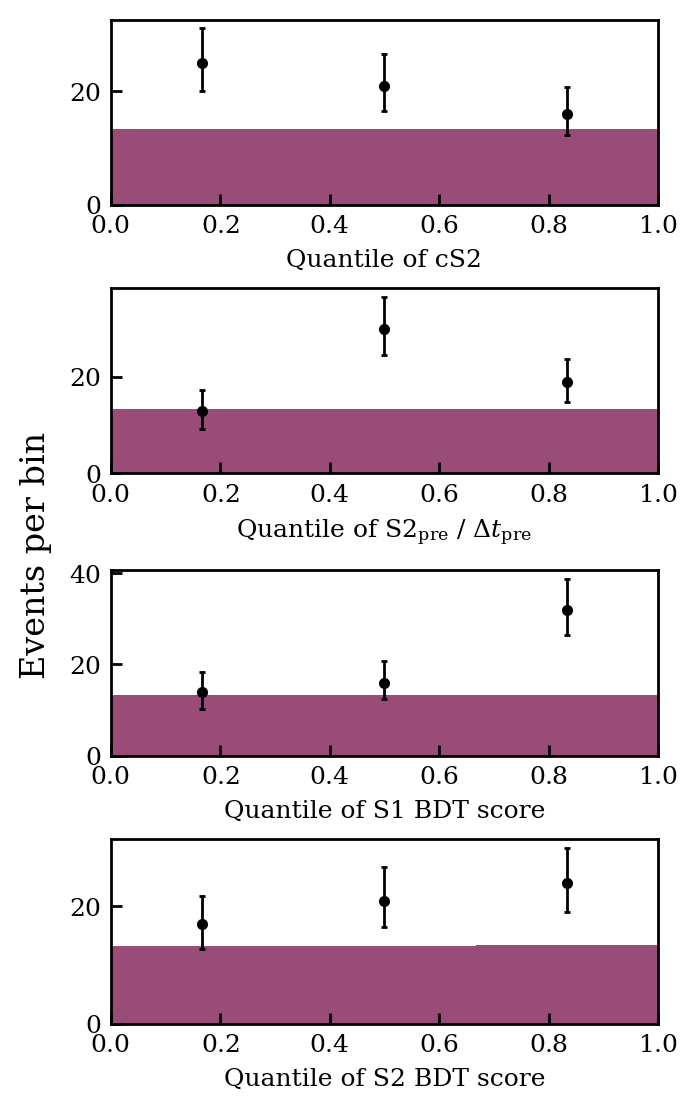

In [8]:
fig, axes = xps.subplots(nrows=4, ncols=1, rescale=(1.0, 2.0))

for i, label in enumerate(axis_labels.keys()):
    h_data = 0
    h_templates = 0
    for sr in ["sr0", "sr1", "sr2"]:
        h_data += np.histogram(data[sr][label], bins=binning[sr][label])[0]
        h_templates += templates[sr].project(axis=i).histogram * livetimes[sr]
    bins = np.linspace(0, 1, 4)
    axes[i].fill_between(
        bins,
        0,
        np.hstack([0, h_templates]),
        step="pre",
        facecolor="#9A4C78",
        edgecolor=None,
    )
    ylow, yhigh = poisson_1s_interval(h_data, fc=True)
    axes[i].errorbar(
        (bins[1:] + bins[:-1]) / 2,
        y=h_data,
        yerr=[h_data - ylow, yhigh - h_data],
        color="k",
        fmt="o",
    )
    axes[i].set_xlabel(axis_labels[label])
    axes[i].set_xlim(0, 1)
    axes[i].set_ylim(bottom=0)
fig.supylabel("Events per bin")

plt.show()

# Limits

In [9]:
limits = pd.read_csv("limits/sr2/xenonnt_2026_wimp_si.csv", index_col=0)

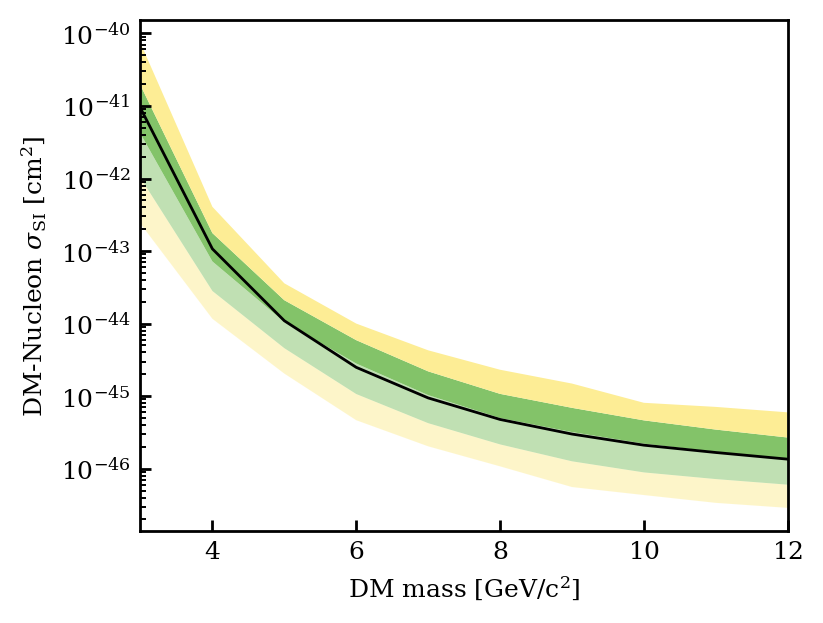

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(4, 3))

ax.fill_between(
    limits["mass"],
    limits["sensitivity_-2"],
    limits["sensitivity_-1"],
    facecolor=xps.colors["2sigma_yellow"],
    edgecolor=None,
    alpha=0.5,
)
ax.fill_between(
    limits["mass"],
    limits["sensitivity_-1"],
    limits["sensitivity_0"],
    facecolor=xps.colors["1sigma_green"],
    edgecolor=None,
    alpha=0.5,
)
ax.fill_between(
    limits["mass"],
    limits["sensitivity_0"],
    limits["sensitivity_1"],
    facecolor=xps.colors["1sigma_green"],
    edgecolor=None,
)
ax.fill_between(
    limits["mass"],
    limits["sensitivity_1"],
    limits["sensitivity_2"],
    facecolor=xps.colors["2sigma_yellow"],
    edgecolor=None,
)
ax.plot(
    limits["mass"],
    limits["upper_limit"],
)

ax.set_yscale("log")
ax.set_xlim(limits["mass"].iloc[0], limits["mass"].iloc[-1])
ax.set_xlabel("DM mass [GeV/c$^2$]")
ax.set_ylabel("DM-Nucleon $\\sigma_\\mathrm{SI}$ [cm$^2$]")

plt.show()

# Plot detection efficiency

The monoenergetic NR templates are used to build the solar neutrino and light dark matter templates, given their respective NR spectra. The four-dimensional binned distribution for each component can be accessed through the `.histogram` attribute of the object returned by `inference_interface.template_to_multihist`.

In [11]:
mono_energies = np.linspace(0.5, 5.0, 46)

In [12]:
efficiency = dict()
for sr in ["sr0", "sr1", "sr2"]:
    efficiency[sr] = list()
    for T in mono_energies:
        efficiency[sr].append(
            inference_interface.template_to_multihist(
                f"templates/{sr}/mono/template_XENONnT_{sr}_mono_{T:.3f}_cevns_tly_0.0_tqy_0.0.h5",
                hist_name="template",
            ).n
        )

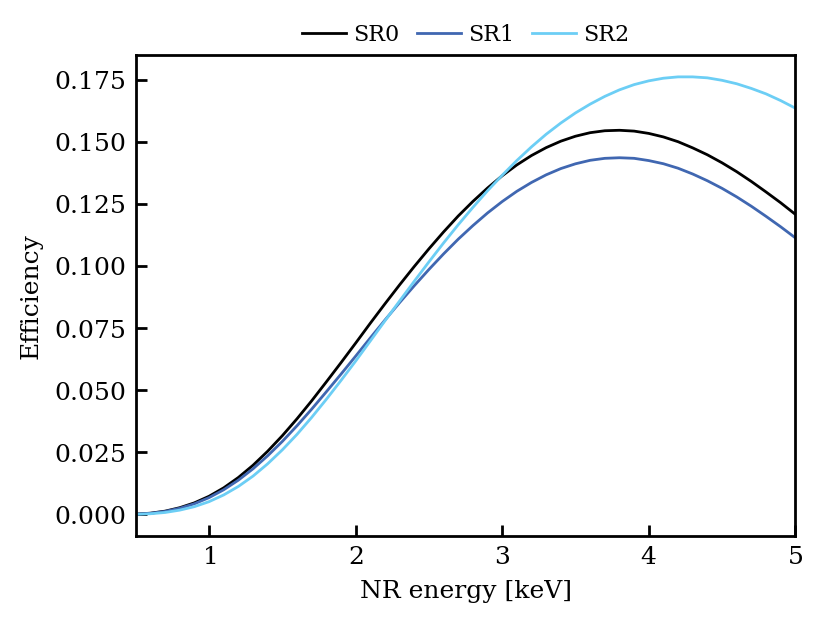

In [13]:
fig, ax = plt.subplots(1, 1, figsize=(4, 3))

for sr in ["sr0", "sr1", "sr2"]:
    ax.plot(mono_energies, efficiency[sr], label=sr.upper())

ax.legend(ncols=3)
ax.set_xlim(mono_energies[0], mono_energies[-1])
ax.set_xlabel("NR energy [keV]")
ax.set_ylabel("Efficiency")

plt.show()